# SECTION 1 — INSTALL DEPENDENCIES

In [ ]:
!pip install datasets


# SECTION 2 — IMPORTS & DATASET LOADING

In [ ]:
from datasets import load_dataset

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from PIL import Image
import warnings
from functools import partial
import tensorflow as tf
from tensorflow import keras
warnings.filterwarnings('ignore')

# reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# load dataset
ds = load_dataset("Hemg/AI-Generated-vs-Real-Images-Datasets")
print("Dataset loaded.")
print(ds)


README.md:   0%|          | 0.00/590 [00:00<?, ?B/s]

data/train-00000-of-00006-336b26d54a26e1(…):   0%|          | 0.00/91.2M [00:00<?, ?B/s]

data/train-00001-of-00006-8ad2d550254dea(…):   0%|          | 0.00/25.9M [00:00<?, ?B/s]

data/train-00002-of-00006-ac8970f21c0418(…):   0%|          | 0.00/339M [00:00<?, ?B/s]

data/train-00003-of-00006-f635132ef309a7(…):   0%|          | 0.00/311M [00:00<?, ?B/s]

data/train-00004-of-00006-1101eaf5152e1c(…):   0%|          | 0.00/40.5M [00:00<?, ?B/s]

data/train-00005-of-00006-4bd152a5ab76db(…):   0%|          | 0.00/565M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/152710 [00:00<?, ? examples/s]

Dataset loaded.
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 152710
    })
})


# SECTION 3 — DATA PREPROCESSING & tf.data PIPELINE


In [ ]:
split_ds = ds["train"].train_test_split(test_size=0.2, seed=42)

train_ds = split_ds["train"]
val_ds = split_ds["test"]

In [ ]:
from PIL import Image as PILImage
IMG_SIZE   = 64
BATCH_SIZE = 32

# --- Compute normalization constants from a sample (200 images) ---
SAMPLE_N = 200
sample_indices = np.random.choice(len(ds['train']), SAMPLE_N, replace=False)
means_r, means_g, means_b = [], [], []

for i in sample_indices:
    img = ds['train'][int(i)]['image'].convert('RGB')
    arr = np.array(img) / 255.0
    means_r.append(arr[:, :, 0].mean())
    means_g.append(arr[:, :, 1].mean())
    means_b.append(arr[:, :, 2].mean())

NORM_MEAN = [np.mean(means_r), np.mean(means_g), np.mean(means_b)]
NORM_STD  = [np.std(means_r) + 1e-6, np.std(means_g) + 1e-6, np.std(means_b) + 1e-6]
print(f"Normalization — mean: {[round(m,3) for m in NORM_MEAN]}, std: {[round(s,3) for s in NORM_STD]}")

# --- 70/15/15 split ---
full = ds['train']
n        = len(full)
n_train  = int(0.70 * n)
n_val    = int(0.15 * n)
n_test   = n - n_train - n_val

indices       = np.random.permutation(n)
train_hf = full.select(indices[:n_train])
val_hf   = full.select(indices[n_train:n_train + n_val])
test_hf  = full.select(indices[n_train + n_val:])
print(f"Split — Train: {len(train_hf)} | Val: {len(val_hf)} | Test: {len(test_hf)}")

# --- Preprocessing: resize + normalize, handles grayscale/RGBA robustly ---
mean_tf = tf.constant(NORM_MEAN, dtype=tf.float32)
std_tf  = tf.constant(NORM_STD,  dtype=tf.float32)

def preprocess_tf(image, label):
    def to_rgb(img):
        img = img.numpy()
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        pil = PILImage.fromarray(img.astype(np.uint8)).convert("RGB")
        pil = pil.resize((IMG_SIZE, IMG_SIZE))
        return np.array(pil, dtype=np.float32) / 255.0

    image = tf.py_function(to_rgb, [image], tf.float32)
    image = tf.ensure_shape(image, (IMG_SIZE, IMG_SIZE, 3))
    image = (image - mean_tf) / std_tf
    return image, label

# --- Build tf.data pipelines via generator (avoids shape mismatch errors) ---
def make_tf_dataset(hf_dataset, shuffle):
    def generator():
        for ex in hf_dataset:
            yield ex["image"], ex["label"]

    ds_tf = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=None, dtype=tf.uint8),
            tf.TensorSpec(shape=(),   dtype=tf.int64)
        )
    )
    if shuffle:
        ds_tf = ds_tf.shuffle(1000)
    return (
        ds_tf
        .map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

train_tf = make_tf_dataset(train_hf, shuffle=True)
val_tf   = make_tf_dataset(val_hf,   shuffle=False)
test_tf  = make_tf_dataset(test_hf,  shuffle=False)

Normalization — mean: [np.float64(0.49), np.float64(0.459), np.float64(0.408)], std: [np.float64(0.111), np.float64(0.129), np.float64(0.172)]
Split — Train: 106897 | Val: 22906 | Test: 22907


# SECTION 5 — CNN MODEL ARCHITECTURE

In [ ]:


DefaultConv2D = partial(keras.layers.Conv2D,
                        kernel_size=3, activation='relu', padding="SAME")

myModel = keras.models.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=2),

    DefaultConv2D(64),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=2),

    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dropout(0.5),
    keras.layers.Dense(32, activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)),

    keras.layers.Dropout(0.3),
    keras.layers.Dense(2, activation='softmax')
])

myModel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,922 (85.63 KB)

 Trainable params: 21,730 (84.88 KB)

 Non-trainable params: 192 (768.00 B)

# SECTION 6 — CNN TRAINING

In [ ]:
from tensorflow.keras.metrics import SparseTopKCategoricalAccuracy
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_scheduler = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.5, patience =2, min_lr = 1e-7, verbose = 1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)


myEpochs = 10
myOptimizer = keras.optimizers.Adam(learning_rate=0.0005)
myLoss = 'sparse_categorical_crossentropy'
myMetrics = ['accuracy']
myModel.compile(loss= myLoss, optimizer = myOptimizer, metrics = myMetrics)
history = myModel.fit(train_tf,
                      validation_data = val_tf,
                      epochs = myEpochs,
                      callbacks = [lr_scheduler, early_stop])

Epoch 1/10
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 264s 76ms/step - accuracy: 0.6793 - loss: 0.6017 - val_accuracy: 0.7659 - val_loss: 0.4468 - learning_rate: 5.0000e-04
Epoch 2/10
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 248s 74ms/step - accuracy: 0.7622 - loss: 0.4552 - val_accuracy: 0.7877 - val_loss: 0.3921 - learning_rate: 5.0000e-04
Epoch 3/10
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 248s 74ms/step - accuracy: 0.7843 - loss: 0.4127 - val_accuracy: 0.8016 - val_loss: 0.3769 - learning_rate: 5.0000e-04
Epoch 4/10
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 251s 75ms/step - accuracy: 0.7960 - loss: 0.3936 - val_accuracy: 0.8260 - val_loss: 0.3501 - learning_rate: 5.0000e-04
Epoch 5/10
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 250s 75ms/step - accuracy: 0.8048 - loss: 0.3818 - val_accuracy: 0.8348 - val_loss: 0.3454 - learning_rate: 5.0000e-04
Epoch 6/10
3341/3341 ━━━━━━━━━━━━━━━━━━━━ 249s 74ms/step - accuracy: 0.8130 - loss: 0.3720 - val_accuracy: 0.8432 - val_loss: 0.3295 - learning_rate: 5.0000e-04
Epoch 7/10
3341/3341 ━━━━━━━━━━━━━

# SECTION 7 — CNN TEST EVALUATION

In [ ]:
test_loss, test_acc = myModel.evaluate(test_tf)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

716/716 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.8753 - loss: 0.2933
Test Loss: 0.2932876944541931
Test Accuracy: 0.8752782940864563


# SECTION 8 — CNN RESULTS & VISUALISATION

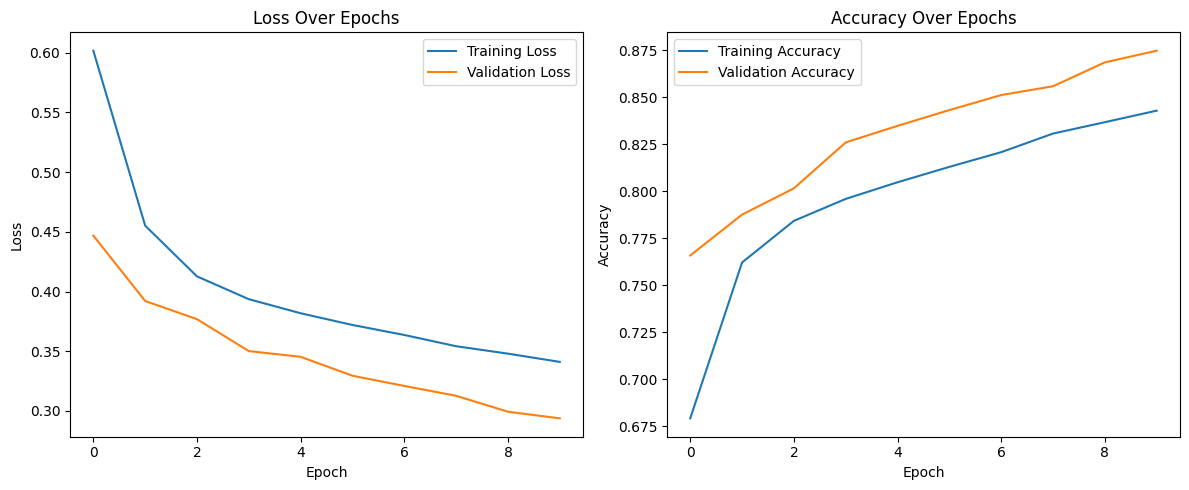

<Figure size 1000x1000 with 0 Axes>

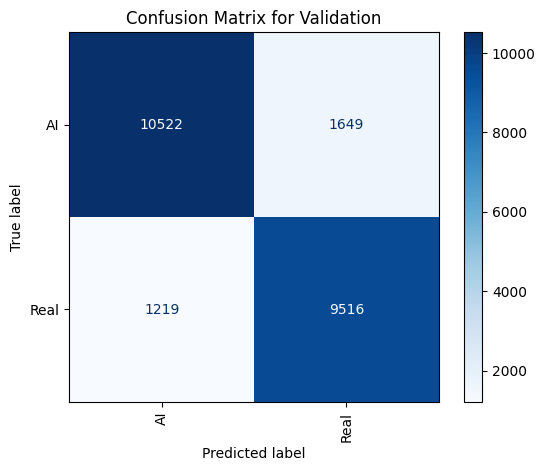

F1 Score for AI: 0.8801 validation
F1 Score for Real: 0.8690 validation


<Figure size 1000x1000 with 0 Axes>

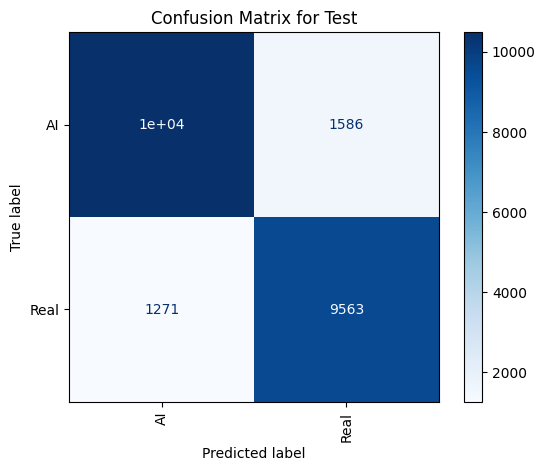

F1 Score for AI: 0.8801 test
F1 Score for Real: 0.8700 test


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import os

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

os.makedirs("../output", exist_ok=True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig("../output/cnn_training_curves.pdf")
plt.show()

class_names = ["AI", "Real"]

y_true = []
y_pred = []

# F1 score for each cla

for x, y in val_tf:
    preds = myModel.predict(x,verbose = 0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 10))
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix for Validation")
plt.savefig("../output/cnn_confusion_validation.pdf")
plt.show()

f1_per_class = f1_score(y_true, y_pred, average=None)

for i, f1 in enumerate(f1_per_class):
    print(f"F1 Score for {class_names[i]}: {f1:.4f} validation")

y_true = []
y_pred = []

for x, y in test_tf:
    preds = myModel.predict(x,verbose = 0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 10))
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix for Test")
plt.savefig("../output/cnn_confusion_test.pdf")
plt.show()

f1_per_class = f1_score(y_true, y_pred, average=None)

for i, f1 in enumerate(f1_per_class):
    print(f"F1 Score for {class_names[i]}: {f1:.4f} test")

# SECTION 9 — ViT + KNN PIPELINE

Dataset loaded.
Dataset({
    features: ['image', 'label'],
    num_rows: 152710
})
Dataset size being used: 3000
Class balance: Counter({0: 1562, 1: 1438})
Label names: ['AiArtData', 'RealArt']
Split — Train: 2100 | Val: 450 | Test: 450


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Using device: cuda
Creating train embeddings...
Creating validation embeddings...
Creating test embeddings...
Train shape: (2100, 768)
Validation shape: (450, 768)
Test shape: (450, 768)
k=1 | Validation F1=0.7473
k=3 | Validation F1=0.7670
k=5 | Validation F1=0.7569
k=7 | Validation F1=0.7489
k=9 | Validation F1=0.7552

Best k based on validation F1: 3

===== Validation Results =====
Accuracy:  0.7689
F1-score:  0.7670
Precision: 0.7775
Recall:    0.7689
PR-AUC:    0.8060

===== Test Results =====
Accuracy:  0.7911
F1-score:  0.7891
Precision: 0.7943
Recall:    0.7911
PR-AUC:    0.7720

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       242
           1       0.82      0.70      0.76       208

    accuracy                           0.79       450
   macro avg       0.80      0.78      0.79       450
weighted avg       0.79      0.79      0.79       450



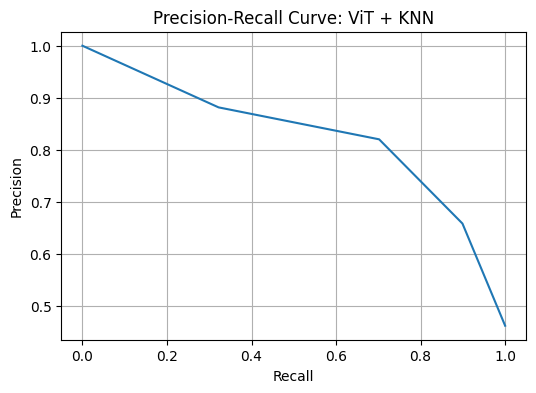

<Figure size 600x600 with 0 Axes>

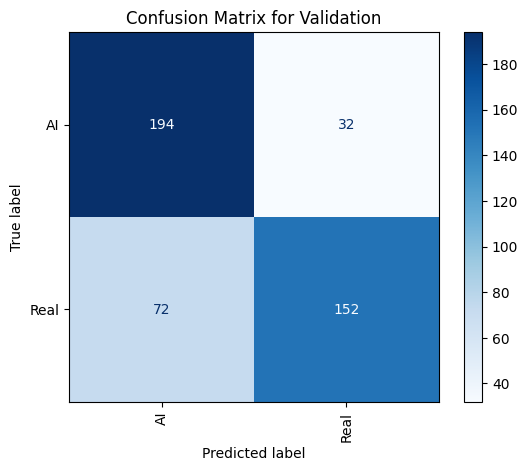

<Figure size 600x600 with 0 Axes>

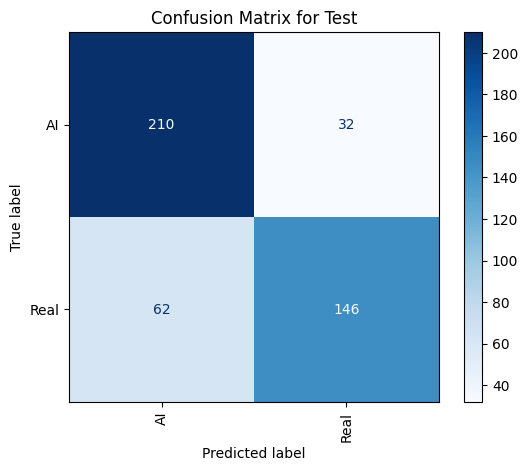

In [ ]:
!pip install -q datasets transformers scikit-learn pillow torch torchvision matplotlib

from datasets import load_dataset
from transformers import ViTImageProcessor, ViTModel
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from PIL import Image
from collections import Counter
import numpy as np
import torch
import matplotlib.pyplot as plt


dataset = load_dataset("Hemg/AI-Generated-vs-Real-Images-Datasets")
full = dataset["train"]

print("Dataset loaded.")
print(full)


sample_size = 3000
if len(full) > sample_size:
    full = full.shuffle(seed=42).select(range(sample_size))

print("Dataset size being used:", len(full))


print("Class balance:", Counter(full["label"]))

if hasattr(full.features["label"], "names"):
    label_names = full.features["label"].names
    print("Label names:", label_names)
else:
    label_names = ["AI", "Real"]

class_names = ["AI", "Real"]


np.random.seed(42)
n = len(full)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

indices = np.random.permutation(n)
train_hf = full.select(indices[:n_train])
val_hf = full.select(indices[n_train:n_train + n_val])
test_hf = full.select(indices[n_train + n_val:])

print(f"Split — Train: {len(train_hf)} | Val: {len(val_hf)} | Test: {len(test_hf)}")

# -------------------------
# ViT processor/model
# -------------------------
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model.to(device)
vit_model.eval()

print("Using device:", device)

def get_embedding(image):
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert("RGB")

    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = vit_model(**inputs)


    return outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

def build_embeddings(hf_dataset):
    X, y = [], []
    for ex in hf_dataset:
        X.append(get_embedding(ex["image"]))
        y.append(ex["label"])
    return np.array(X), np.array(y)

print("Creating train embeddings...")
X_train, y_train = build_embeddings(train_hf)

print("Creating validation embeddings...")
X_val, y_val = build_embeddings(val_hf)

print("Creating test embeddings...")
X_test, y_test = build_embeddings(test_hf)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

k_values = [1, 3, 5, 7, 9]
best_k = None
best_f1 = -1
best_model = None

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    val_pred = knn.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average="weighted")
    print(f"k={k} | Validation F1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_k = k
        best_model = knn

print(f"\nBest k based on validation F1: {best_k}")


val_pred = best_model.predict(X_val)
val_proba = best_model.predict_proba(X_val)[:, 1] if len(np.unique(y_val)) == 2 else None

print("\n===== Validation Results =====")
print(f"Accuracy:  {accuracy_score(y_val, val_pred):.4f}")
print(f"F1-score:  {f1_score(y_val, val_pred, average='weighted'):.4f}")
print(f"Precision: {precision_score(y_val, val_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_val, val_pred, average='weighted'):.4f}")

if val_proba is not None:
    print(f"PR-AUC:    {average_precision_score(y_val, val_proba):.4f}")


test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)[:, 1] if len(np.unique(y_test)) == 2 else None

print("\n===== Test Results =====")
print(f"Accuracy:  {accuracy_score(y_test, test_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, test_pred, average='weighted'):.4f}")
print(f"Precision: {precision_score(y_test, test_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, test_pred, average='weighted'):.4f}")

if test_proba is not None:
    print(f"PR-AUC:    {average_precision_score(y_test, test_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, test_pred))


if test_proba is not None:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, test_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(recall_vals, precision_vals)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve: ViT + KNN")
    plt.grid(True)
    plt.savefig("../output/VIT_Precision_Recall.pdf")
    plt.show()


cm_val = confusion_matrix(y_val, val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=class_names)
plt.figure(figsize=(6, 6))
disp_val.plot(cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix for Validation")
plt.savefig("../output/VIT_confusion_validation.pdf")
plt.show()


cm_test = confusion_matrix(y_test, test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
plt.figure(figsize=(6, 6))
disp_test.plot(cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix for Test")
plt.savefig("../output/VIT_confusion_test.pdf")
plt.show()

# SECTION 10 — CNN vs ViT+KNN FINAL COMPARISON

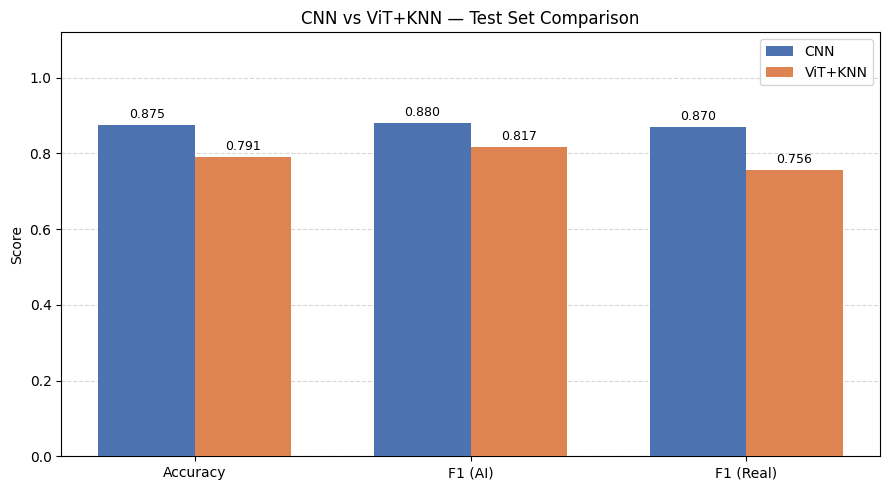

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Paste your actual results here ──────────────────────────────────────────
# CNN results (from myModel.evaluate / f1_score on test_tf)
cnn_metrics = {
    "Accuracy":  test_acc,          # e.g. 0.87  — variable from myModel.evaluate
    "F1 (AI)":   f1_per_class[0],   # last computed f1_per_class for CNN test
    "F1 (Real)": f1_per_class[1],
}

# ViT + KNN results (from sklearn on test set)
vit_metrics = {
    "Accuracy":  accuracy_score(y_test, test_pred),
    "F1 (AI)":   f1_score(y_test, test_pred, average=None)[0],
    "F1 (Real)": f1_score(y_test, test_pred, average=None)[1],
}
# ────────────────────────────────────────────────────────────────────────────

labels  = list(cnn_metrics.keys())
cnn_vals = list(cnn_metrics.values())
vit_vals = list(vit_metrics.values())

x   = np.arange(len(labels))
w   = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, cnn_vals, w, label="CNN",     color="#4C72B0", zorder=3)
bars2 = ax.bar(x + w/2, vit_vals, w, label="ViT+KNN", color="#DD8452", zorder=3)

ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("CNN vs ViT+KNN — Test Set Comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

# Value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("cnn_vs_vit_comparison.png", dpi=150)
plt.savefig("../output/CNN_VS_VIT_Comparison.pdf")
plt.show()